## INITIALIZATION
First attempt to build features -- use 0714 build feature notebook for better code.

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/01 14:43:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/01 14:43:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2025-11-01 14:43:07,862 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/11/01 14:43:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-11-01 14:43:09,436 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-11-01 14:43:11,123 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-11-01 14:43:11,124 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-11-01 14:43

## Build features X

In [4]:
dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']
target_col = ["NETPAY17"]
df_enrollees_cols = ["AGEGRP","SEX","ENROLID","REGION","INDSTRY"]
pilot_stages = ["CKD Stage 3", "CKD Stage 4"]


def build_ckd_stage_case(dx_cols):
    stage_map = {
        "N181": "CKD Stage 1",
        "N182": "CKD Stage 2",
        "N183": "CKD Stage 3",
        "N184": "CKD Stage 4",
        "N185": "CKD Stage 5",
        "N186": "ESRD",
        "N189": "Unspecified"
    }
    # OR‐all the DX columns for each prefix
    expr = None
    for code, label in stage_map.items():
        cond = F.lit(False)
        for c in dx_cols:
            cond = cond | F.col(c).startswith(code)
        expr = F.when(cond, label) if expr is None else expr.when(cond, label)
    return expr

ckd_stage_col = build_ckd_stage_case(dx_cols)

# ◼︎ B) pull CKD claims in 2017–2018, tag with stage, filter to pilot IDs who have Stage3/4 in BOTH years
df_ckd_1718 = (
    df_claims
     .withColumn("YEAR", F.year("SVCDATE"))
     .filter(F.col("YEAR").between(2017,2018))
     .withColumn("CKD_STAGE", ckd_stage_col)
     .filter(F.col("CKD_STAGE").isNotNull())
)

# B1) IDs with Stage3/4 in 2017
ids_2017 = (
    df_ckd_1718
      .filter(F.col("YEAR")==2017)
      .filter(F.col("CKD_STAGE").isin(["CKD Stage 3","CKD Stage 4"]))
      .select("ENROLID").distinct()
)

# B2) IDs with Stage3/4 in 2018
ids_2018 = (
    df_ckd_1718
      .filter(F.col("YEAR")==2018)
      .filter(F.col("CKD_STAGE").isin(["CKD Stage 3","CKD Stage 4"]))
      .select("ENROLID").distinct()
)

# B3) Intersection → pilot IDs
pilot_ids = ids_2017.intersect(ids_2018)


pilot_ids.count()

33595

In [7]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

# 1) Start from your enrol_static (one row per enrollee‐year)
enrol_static = (
    df_enrollment
      .join(pilot_ids, on="ENROLID", how="inner")
      .filter(col("YEAR").between(2017, 2018))
      .select(*df_enrollees_cols, "YEAR")
      .distinct()
)

# 2) Define a window that orders YEAR desc so 2018 comes before 2017
w = Window.partitionBy("ENROLID").orderBy(col("YEAR").desc())

# 3) Assign row numbers and take only the first (i.e. 2018 if it exists, else 2017)
enrol_one = (
    enrol_static
      .withColumn("rn", row_number().over(w))
      .filter(col("rn") == 1)
      .drop("rn", "YEAR")
)

# Now enrol_one is exactly one row per ENROLID,
# sourcing its data from 2018 if available, otherwise from 2017.
enrol_one.show(5, truncate=False)
enrol_one.count()

+------+---+--------+------+-------+
|AGEGRP|SEX|ENROLID |REGION|INDSTRY|
+------+---+--------+------+-------+
|5     |1  |27987501|1     |4      |
|4     |1  |28940901|3     |4      |
|4     |1  |29021902|3     |4      |
|5     |2  |29186305|3     |4      |
|5     |1  |29505001|3     |4      |
+------+---+--------+------+-------+
only showing top 5 rows


33595

In [5]:
# ◼︎ C) Pull *all* claims for those pilots in 2017–2018
pilot_claims = (
    df_claims
      .withColumn("YEAR", F.year("SVCDATE"))
      .join(pilot_ids, on="ENROLID", how="inner")
      .filter(F.col("YEAR").between(2017,2018))
      .orderBy("ENROLID","SVCDATE")
)



# Cost aggregation

In [8]:
from pyspark.sql import functions as F, Window

# ── 0) Your inflation factors ────────────────────────────────
inflation_map = {
    2017: 1.0,
    2018: 1.0685946832951803,
    2019: 1.1371893665903605
}
# Build a Spark map literal: YEAR → factor
infl_map = sum([[F.lit(year), F.lit(factor)] for year, factor in inflation_map.items()], [])
inflation_expr = F.create_map(*infl_map)


# ── 1) Add inflation‐adjusted cost to the raw claims DF ───────
df_adj_claims = (
    pilot_claims
      .filter(F.col("RX").isNotNull())
      # look up the factor by YEAR
      .withColumn("inflation_factor", inflation_expr[F.col("YEAR")])
      # normalize all costs back to 2017 dollars
      .withColumn("NETPAY17", F.col("NETPAY") / F.col("inflation_factor"))
      # keep everything *and* the new NETPAY17 for later
      .drop("inflation_factor")
)

# Now df_adj_claims is identical to pilot_ckd_claims except it has NETPAY17


# ── 2) Build the per‐enrollee annual summary ──────────────────
agg_cost = (
    df_adj_claims
      .groupBy("ENROLID", "REGION", "YEAR")
      .agg(
         F.sum("NETPAY17").alias("annual_cost17"),
      )
)

# ── 3) Flag the top‐25% in each REGION×YEAR combination ───────
w = Window.partitionBy("REGION", "YEAR").orderBy("annual_cost17")

df_stratum = (
    agg_cost
      .withColumn("ecdf", F.cume_dist().over(w))
      .withColumn(
          "cost_stratum",
          F.when(F.col("ecdf") < 0.25, F.lit(0))
           .when(F.col("ecdf") < 0.75, F.lit(1))
           .otherwise(F.lit(2))
      )
      .select("ENROLID", "YEAR", "cost_stratum")
)

# 3) Pivot YEAR → two columns
df_cost_stratum = (
    df_stratum
      .groupBy("ENROLID")
      .pivot("YEAR", [2017, 2018])
      .agg(F.first("cost_stratum"))
      .withColumnRenamed("2017", "cost_stratum_2017")
      .withColumnRenamed("2018", "cost_stratum_2018")
      
).drop("NETPAY17","annual_cost17","ecdf","cost_stratum")



df_cost_stratum.show(5)
# pilot_ckd_claims (and df_adj_claims) remain available for row‐level work


+----------+-----------------+-----------------+
|   ENROLID|cost_stratum_2017|cost_stratum_2018|
+----------+-----------------+-----------------+
|3659365802|                2|                2|
|2111546103|                1|                1|
|4225649202|                1|                0|
|2886195902|                1|                2|
|3145985201|                2|                2|
+----------+-----------------+-----------------+
only showing top 5 rows


In [9]:
import seaborn as sns
# 1) (Optionally) take a sample so you don't OOM when converting:
spark_sample = agg_cost.sample(False, 0.1, seed=42)  

# 2) Convert to pandas:
df_ranked_pd = spark_sample.toPandas()
plt.figure(figsize=(10,6))
sns.violinplot(
    x="REGION",
    y="cost_ecdf",
    data=df_ranked_pd,
    inner="quartile",   # shows median & IQR
    scale="width",      # all violins have same maximum width
)
plt.title("Distribution of ECDF-Normalized Cost by Region")
plt.xlabel("Region")
plt.ylabel("Cost ECDF (0–1)")
plt.show()


ValueError: Could not interpret value `cost_ecdf` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

# Track CKD stage quarterly

In [15]:
from pyspark.sql import functions as F, Window

# ─── 1) Define year/quarter on every CKD claim ───────────────
df_q = (
    pilot_claims
      .withColumn("CKD_STAGE", ckd_stage_col)
      .filter(F.col("CKD_STAGE").isNotNull())
      .withColumn("YEAR", F.year("SVCDATE"))
      .withColumn("QUARTER", F.quarter("SVCDATE"))
)

# ─── 2) For every enrollee × quarter, grab the *most recent* stage in that quarter ──
w_q = Window.partitionBy("ENROLID","YEAR","QUARTER") \
            .orderBy(F.col("SVCDATE").desc())

df_most_recent = (
    df_q
      .withColumn("rn_q", F.row_number().over(w_q))
      .filter(F.col("rn_q") == 1)
      .select("ENROLID","YEAR","QUARTER","CKD_STAGE")
)

# ─── 3) Build the full grid of ENROLID × YEAR × QUARTER for your window ─────────
#    so that missing quarters show up (we’ll fill them next)
years = [2017,2018]   # your pilot years
quarters = [1,2,3,4]

from itertools import product
full = spark.createDataFrame(
    [(e,y,q) for e in df_most_recent.select("ENROLID").distinct().toPandas()["ENROLID"]
           for y,q in product(years,quarters)],
    schema=["ENROLID","YEAR","QUARTER"]
)

# ─── 4) Left‐join the known most‐recent‐in‐quarter onto the full grid ────────────
df_q_full = (
    full
      .join(df_most_recent, on=["ENROLID","YEAR","QUARTER"], how="left")
      .orderBy("ENROLID","YEAR","QUARTER")
)

# ─── 5) Carry–forward last observed stage to fill quarters with no new dx ─────────
w_ff = Window.partitionBy("ENROLID") \
             .orderBy("YEAR","QUARTER") \
             .rowsBetween(Window.unboundedPreceding, 0)

df_q_filled = (
    df_q_full
      .withColumn(
         "stage_quarterly",
         F.last("CKD_STAGE", ignorenulls=True).over(w_ff)
      )
      .select("ENROLID","YEAR","QUARTER","stage_quarterly")
)


# ◼︎ G) Pivot wide: one row per ENROLID, cols 2017Q1…2018Q4
yq_cols = [f"{y}Q{q}" for y in years for q in quarters]

df_stage_pivot = (
    df_q_filled
      .withColumn("YQ", F.concat_ws("Q",F.col("YEAR"),F.col("QUARTER")))
      .groupBy("ENROLID")
      .pivot("YQ", yq_cols)
      .agg(F.first("stage_quarterly"))
)
# df_stage_pivot now has columns:
#   ENROLID, 2017Q1, 2017Q2, …, 2018Q4
# each cell is the CKD stage active in that quarter (carry‐forward if none new)


In [24]:
df_stage_pivot.show(10)

+--------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
|             ENROLID|     2017Q1|     2017Q2|     2017Q3|     2017Q4|     2018Q1|     2018Q2|     2018Q3|     2018Q4|
+--------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
|602902.0000000000...|       NULL|CKD Stage 4|CKD Stage 4|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 4|
|26998101.00000000...|       NULL|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 2|CKD Stage 2|
|27753401.00000000...|       NULL|Unspecified|Unspecified|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|
|27871701.00000000...|       NULL|       NULL|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|
|28852901.00000000...|       NULL|CKD Stage 3|CKD Stage 3|CKD Stage 3|CKD Stage 3|Unspecified|CKD Stage 3|CKD Stage 3|
|28940901.00000000...|       NULL|       NULL|CK

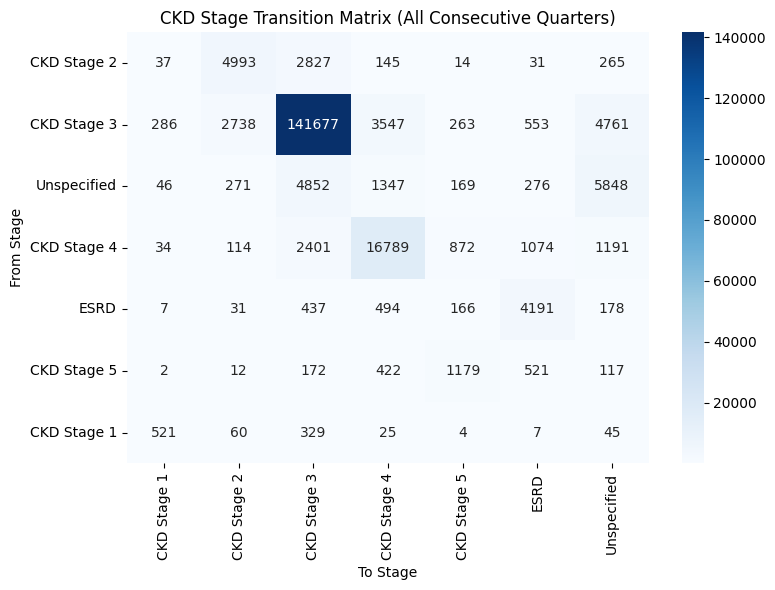

In [32]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1) ensure you have ENROLID, q_idx, and stage_quarterly columns
#    (q_idx = (YEAR-2017)*4 + QUARTER)

df_q = (
  df_q_filled
    .withColumn("q_idx", (F.col("YEAR")-F.lit(2017))*4 + F.col("QUARTER"))
    .select("ENROLID", "q_idx", "stage_quarterly")
)

# 2) use lag() to get the prior quarter's stage
w = Window.partitionBy("ENROLID").orderBy("q_idx")
df_pairs = (
  df_q
    .withColumn("prev_stage", F.lag("stage_quarterly").over(w))
    .filter("prev_stage IS NOT NULL")
    .select("prev_stage", F.col("stage_quarterly").alias("next_stage"))
)

# 3) count each transition
df_counts = (
  df_pairs
    .groupBy("prev_stage", "next_stage")
    .count()
)

# 4) pivot to a matrix
df_mat = (
  df_counts
    .groupBy("prev_stage")
    .pivot("next_stage")
    .sum("count")
    .fillna(0)
)

# 5) convert to Pandas & plot with seaborn
pdf = df_mat.toPandas().set_index("prev_stage")
import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(pdf, annot=True, fmt="g", cmap="Blues")
plt.title("CKD Stage Transition Matrix (All Consecutive Quarters)")
plt.xlabel("To Stage")
plt.ylabel("From Stage")
plt.tight_layout()
plt.show()


# Get CKD-related comorbidities and one-hot encode these
Explodes all ICD‐10 Dx columns from your pilot_claims DataFrame.

Filters out any CKD codes (N18xx).

Counts the frequency of each remaining raw code.

Keeps only the top raw codes you care about (say the top 50).

Maps each raw code into your clinical “bucket” (falling back to the raw code if unmapped).

Aggregates bucket counts and pulls out the top 10 buckets.

In [56]:
# dialysis ICD10
df_filtered.filter(F.col("raw_code")=="Z992").count()

152552

In [10]:
df_exploded = (
    pilot_claims
      .select("ENROLID", *dx_cols)
      .withColumn("raw_code", F.explode(F.array(*[F.col(c) for c in dx_cols])))
      .filter(F.col("raw_code").isNotNull())
)

# 3) Filter out any N18xx (CKD) codes
df_filtered = df_exploded.filter(~F.col("raw_code").startswith("N18"))

# 4) Count raw_code frequencies and keep top K (e.g. 50)
top_raw = (
    df_filtered
      .groupBy("raw_code")
      .count()
      .orderBy(F.desc("count"))
      .limit(50)
)

# 5) Bring that list back to filter & bucket
top_codes = [row["raw_code"] for row in top_raw.collect()]
print("Top codes; ", top_codes)
df_top = df_filtered.filter(F.col("raw_code").isin(top_codes))

# 6) Define your grouping map (example buckets)
code_map = {
    "D631": "Anemia",
    "D509": "Anemia",
    "D649": "Anemia",

    "I10":  "Hypertension",
    "I129": "Hypertension",
    "E1122":"Type 2 Diabetes",
    "E1121":"Type 2 Diabetes",
    "E1165":"Type 2 Diabetes",

    "E119": "Type 2 Diabetes",
    "E559": "Vitamin D Deficiency",
    "R809": "Proteinuria",
    "E785": "Hyperlipidemia",
    "E782": "Hyperlipidemia",
    "N2581":"Hyperparathyroidism",
    "N179": "Acute Kidney Failure",
    "Z940": "Kidney Transplant",
    "Z79899":"Other Long-term Drug Therapy",
    "E039": "Hypothyroidism"
}
mapping_expr = F.create_map(*[F.lit(x) for kv in code_map.items() for x in kv])

# 7) Assign buckets (fallback to raw_code)
df_bucketed = df_top.withColumn(
    "bucket",
    F.coalesce(
      mapping_expr.getItem(F.col("raw_code")),
      F.col("raw_code")
    )
)

# 8) Count buckets and pull top 10
top10_buckets = (
    df_bucketed
      .groupBy("bucket")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

top10_buckets.show(truncate=False)


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


Top codes;  ['I10', 'D631', 'E1122', 'E119', 'E785', 'I129', 'N179', 'D509', 'N2581', 'Z940', 'D649', 'E559', 'E1165', 'Z79899', 'E039', 'G4733', 'I130', 'E782', 'Z992', 'I2510', 'A419', 'Z0000', 'I120', 'D689', 'Z23', 'E6601', 'M545', 'E1121', 'R809', 'E669', 'N390', 'E7800', 'E872', 'E875', 'E11621', 'I509', 'Z01818', 'R079', 'C9000', 'K219', 'E1140', 'R0602', 'J189', 'M109', 'I214', 'Z794', 'E1142', 'M542', 'E860', 'Z5111']


+----------------------------+-------+
|bucket                      |count  |
+----------------------------+-------+
|Hypertension                |1316645|
|Type 2 Diabetes             |1115052|
|Anemia                      |950906 |
|Hyperlipidemia              |553170 |
|Acute Kidney Failure        |319426 |
|Hyperparathyroidism         |245252 |
|Kidney Transplant           |226104 |
|Vitamin D Deficiency        |219892 |
|Other Long-term Drug Therapy|185210 |
|Hypothyroidism              |173936 |
+----------------------------+-------+



In [11]:
from pyspark.sql import functions as F

# 1) Collect the top-10 bucket names into a Python list
top10_list = [row["bucket"] for row in top10_buckets.collect()]

# 2) Filter your bucketed DataFrame to only those top-10
df_top10 = df_bucketed.filter(F.col("bucket").isin(top10_list))

# 3) For each ENROLID and bucket, flag presence once
df_flag = (
    df_top10
      .select("ENROLID", "bucket")
      .dropDuplicates()               # one row per enrollee‐bucket
      .withColumn("has_flag", F.lit(1))
)

# 4) Pivot wide so each bucket becomes its own binary column
df_diagnoses = (
    df_flag
      .groupBy("ENROLID")
      .pivot("bucket", top10_list)    # ensure consistent column order
      .agg(F.first("has_flag"))
      .fillna(0)                      # missing ⇒ 0
)

# 5) (Optional) rename columns more prettily
for b in top10_list:
    df_diagnoses = df_diagnoses.withColumnRenamed(b, f"has_{b.replace(' ','_')}")

# 6) Now df_features has one row per ENROLID and 10 columns of 0/1 flags
df_diagnoses.show(5)


+---------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------------+------------------+
|  ENROLID|has_Hypertension|has_Type_2_Diabetes|has_Anemia|has_Hyperlipidemia|has_Acute_Kidney_Failure|has_Hyperparathyroidism|has_Kidney_Transplant|has_Vitamin_D_Deficiency|has_Other_Long-term_Drug_Therapy|has_Hypothyroidism|
+---------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------------+------------------+
| 28940901|               1|                  0|         0|                 1|                       0|                      0|                    0|                       1|                               1|                 0|
|131734201|               1|                  0|         1|                 0|              

# Join static df with diagnoses, cost, and CKD stages

In [12]:

df_utilization = (
    pilot_claims
      .groupBy("ENROLID")
      .pivot("YEAR", [2017, 2018])
      .agg(
         # count any non‐null column, e.g. ENROLID, to get row counts
         F.count("ENROLID").alias("util_count")
      )
)

# Optionally rename the pivoted columns to be clearer:
df_utilization = (
    df_utilization
      .withColumnRenamed("2017", "util_2017")
      .withColumnRenamed("2018", "util_2018")
)

df_utilization.show(5, truncate=False)


+----------+---------+---------+
|ENROLID   |util_2017|util_2018|
+----------+---------+---------+
|1446721201|59       |106      |
|3174574101|267      |318      |
|2886195902|193      |450      |
|3062096401|243      |990      |
|3062536202|196      |116      |
+----------+---------+---------+
only showing top 5 rows


In [13]:
df_enrol_with_feats = (
    enrol_one                # your one-row-per-ENROLID+YEAR
      .join(df_diagnoses, "ENROLID", how="left")
      .fillna({f"has_{b.replace(' ','_')}": 0 for b in top10_list})
)

df_enrol_with_feats.show(5)
print(df_enrol_with_feats.select("ENROLID").distinct().count())



+--------+------+---+------+-------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------------+------------------+
| ENROLID|AGEGRP|SEX|REGION|INDSTRY|has_Hypertension|has_Type_2_Diabetes|has_Anemia|has_Hyperlipidemia|has_Acute_Kidney_Failure|has_Hyperparathyroidism|has_Kidney_Transplant|has_Vitamin_D_Deficiency|has_Other_Long-term_Drug_Therapy|has_Hypothyroidism|
+--------+------+---+------+-------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------------+------------------+
|27987501|     5|  1|     1|      4|               1|                  1|         1|                 1|                       0|                      0|                    1|                       0|                               1|            

33595


In [16]:
from pyspark.sql import functions as F

quarters = ["2017Q1","2017Q2","2017Q3","2017Q4",
            "2018Q1","2018Q2","2018Q3","2018Q4"]

df_numeric = df_stage_pivot

for q in quarters:
    df_numeric = df_numeric.withColumn(
        q,
        F.when(
            # if the string contains at least one digit
            F.col(q).rlike(r".*\d+.*"),
            # extract that digit group and cast to int
            F.regexp_extract(F.col(q), r"(\d+)", 1).cast("int")
        ).otherwise(
            # else (NULL or empty or non‐digit), set –1
            F.lit(-1)
        )
    )

df_numeric.show()


+--------------------+------+------+------+------+------+------+------+------+
|             ENROLID|2017Q1|2017Q2|2017Q3|2017Q4|2018Q1|2018Q2|2018Q3|2018Q4|
+--------------------+------+------+------+------+------+------+------+------+
|602902.0000000000...|    -1|     4|     4|     3|     3|     3|     3|     4|
|26998101.00000000...|    -1|     3|     3|     3|     3|     3|     2|     2|
|27753401.00000000...|    -1|    -1|    -1|     3|     3|     3|     3|     3|
|27871701.00000000...|    -1|    -1|     3|     3|     3|     3|     3|     3|
|28852901.00000000...|    -1|     3|     3|     3|     3|    -1|     3|     3|
|28940901.00000000...|    -1|    -1|     3|     3|     3|     3|     3|     3|
|28982501.00000000...|     3|     3|     3|     3|     3|     3|     3|     3|
|29020702.00000000...|    -1|    -1|     3|     3|     3|     3|     3|     3|
|29159801.00000000...|    -1|    -1|    -1|     2|     2|     2|     2|     3|
|29481702.00000000...|    -1|    -1|    -1|     3|  

In [17]:
# join keys
keys = ["ENROLID"]

assert df_enrol_with_feats.select("ENROLID").distinct().count() == df_enrol_with_feats.count()
assert df_numeric.select("ENROLID").distinct().count() == df_numeric.count()
assert df_cost_stratum.select("ENROLID").distinct().count() == df_cost_stratum.count()
assert df_utilization.select("ENROLID").distinct().count() == df_utilization.count()

df_full = (
    df_enrol_with_feats
      .join(df_numeric, on=keys, how="inner") # stage of CKD by quarter
      .join(df_cost_stratum, on=keys, how="inner")
      .join(df_utilization,on=keys,how="inner"))



In [18]:
df_full.write.mode("overwrite").parquet("df_0714_2017_18_stage_pivot_diagnoses_cost_stratum.parquet")

In [34]:
# ── 1)  Tidy the data: turn the two columns into (YEAR, stratum) rows
counts = (
    df_cost_stratum
      # stack(2, colName1, value1, colName2, value2 …)
      .selectExpr("stack(2, 2017, cost_stratum_2017, 2018, cost_stratum_2018) as (YEAR, stratum)")
      .groupBy("YEAR", "stratum")
      .count()                              # how many ENROLIDs in each bucket
      .orderBy("YEAR", "stratum")
)
print(df_cost_stratum.select("ENROLID").distinct().count())
# sanity-check
counts.show()

33595


+----+-------+-----+
|YEAR|stratum|count|
+----+-------+-----+
|2017|      0| 8383|
|2017|      1|16801|
|2017|      2| 8411|
|2018|      0| 8379|
|2018|      1|16805|
|2018|      2| 8411|
+----+-------+-----+



In [19]:
df_full.show(5) #

+--------+------+---+------+-------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------------+------------------+------+------+------+------+------+------+------+------+-----------------+-----------------+---------+---------+
| ENROLID|AGEGRP|SEX|REGION|INDSTRY|has_Hypertension|has_Type_2_Diabetes|has_Anemia|has_Hyperlipidemia|has_Acute_Kidney_Failure|has_Hyperparathyroidism|has_Kidney_Transplant|has_Vitamin_D_Deficiency|has_Other_Long-term_Drug_Therapy|has_Hypothyroidism|2017Q1|2017Q2|2017Q3|2017Q4|2018Q1|2018Q2|2018Q3|2018Q4|cost_stratum_2017|cost_stratum_2018|util_2017|util_2018|
+--------+------+---+------+-------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------------+------------------+------+------+------+